In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("autos.csv", encoding="Latin-1")


In [3]:
##3###

In [4]:
print("Initial columns:\n", df.columns)
print(df.head())


Initial columns:
 Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')
           dateCrawled                            name  seller offerType  \
0  2016-03-24 11:52:17                      Golf_3_1.6  privat   Angebot   
1  2016-03-24 10:58:45            A5_Sportback_2.7_Tdi  privat   Angebot   
2  2016-03-14 12:52:21  Jeep_Grand_Cherokee_"Overland"  privat   Angebot   
3  2016-03-17 16:54:04              GOLF_4_1_4__3TÜRER  privat   Angebot   
4  2016-03-31 17:25:20  Skoda_Fabia_1.4_TDI_PD_Classic  privat   Angebot   

   price abtest vehicleType  yearOfRegistration    gearbox  powerPS  model  \
0    480   test         NaN                1993    manuell        0   golf   
1  18300   test       coupe                

In [9]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  notRepairedDamage    299468 non-nu

In [11]:
33#3##

33

In [13]:
df = df.rename(columns={
    "brand": "make",                
    "model": "model",                
    "yearOfRegistration": "year",    
    "kilometer": "mileage",         
    "fuelType": "fuel_type",         
    "gearbox": "transmission",       
    "price": "selling_price"         
})


In [15]:
df["engine_size"] = np.nan  
df["owners"] = np.nan


In [17]:
3#3#3#33333#

3

In [19]:
print("\nRenamed columns:\n", df[[
    "make","model","year","mileage",
    "engine_size","fuel_type",
    "transmission","owners","selling_price"
]].head())



Renamed columns:
          make  model  year  mileage  engine_size fuel_type transmission  \
0  volkswagen   golf  1993   150000          NaN    benzin      manuell   
1        audi    NaN  2011   125000          NaN    diesel      manuell   
2        jeep  grand  2004   125000          NaN    diesel    automatik   
3  volkswagen   golf  2001   150000          NaN    benzin      manuell   
4       skoda  fabia  2008    90000          NaN    diesel      manuell   

   owners  selling_price  
0     NaN            480  
1     NaN          18300  
2     NaN           9800  
3     NaN           1500  
4     NaN           3600  


In [21]:
missing_report = df[[
    "make","model","year","mileage",
    "engine_size","fuel_type",
    "transmission","owners","selling_price"
]].isnull().sum()
print("\nMissing values per column:\n", missing_report)



Missing values per column:
 make                  0
model             20484
year                  0
mileage               0
engine_size      371528
fuel_type         33386
transmission      20209
owners           371528
selling_price         0
dtype: int64


In [23]:
percent_missing = (missing_report / len(df)) * 100
print("\n% Missing values:\n", percent_missing)



% Missing values:
 make               0.000000
model              5.513447
year               0.000000
mileage            0.000000
engine_size      100.000000
fuel_type          8.986133
transmission       5.439429
owners           100.000000
selling_price      0.000000
dtype: float64


In [25]:
3##3###3###

3

In [27]:
df["make"] = df["make"].fillna("Unknown")
df["model"] = df["model"].fillna("Unknown")
df["fuel_type"] = df["fuel_type"].fillna("Unknown")
df["transmission"] = df["transmission"].fillna("Unknown")


In [29]:
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")
df["selling_price"] = pd.to_numeric(df["selling_price"], errors="coerce")


In [31]:
df["engine_size"] = df["engine_size"].astype(float)
df["owners"] = df["owners"].astype(float)



In [33]:
print(df[["year","mileage","selling_price"]].describe())


                year        mileage  selling_price
count  371528.000000  371528.000000   3.715280e+05
mean     2004.577997  125618.688228   1.729514e+04
std        92.866598   40112.337051   3.587954e+06
min      1000.000000    5000.000000   0.000000e+00
25%      1999.000000  125000.000000   1.150000e+03
50%      2003.000000  150000.000000   2.950000e+03
75%      2008.000000  150000.000000   7.200000e+03
max      9999.000000  150000.000000   2.147484e+09


In [35]:
cleaned_df = df[[
    "make","model","year","mileage",
    "engine_size","fuel_type","transmission",
    "owners","selling_price"
]]


In [37]:
print("\nCleaned dataset sample:\n", cleaned_df.head())



Cleaned dataset sample:
          make    model  year  mileage  engine_size fuel_type transmission  \
0  volkswagen     golf  1993   150000          NaN    benzin      manuell   
1        audi  Unknown  2011   125000          NaN    diesel      manuell   
2        jeep    grand  2004   125000          NaN    diesel    automatik   
3  volkswagen     golf  2001   150000          NaN    benzin      manuell   
4       skoda    fabia  2008    90000          NaN    diesel      manuell   

   owners  selling_price  
0     NaN            480  
1     NaN          18300  
2     NaN           9800  
3     NaN           1500  
4     NaN           3600  


In [39]:
print("\nCleaned dataset sample:\n", cleaned_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   make           371528 non-null  object 
 1   model          371528 non-null  object 
 2   year           371528 non-null  int64  
 3   mileage        371528 non-null  int64  
 4   engine_size    0 non-null       float64
 5   fuel_type      371528 non-null  object 
 6   transmission   371528 non-null  object 
 7   owners         0 non-null       float64
 8   selling_price  371528 non-null  int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 25.5+ MB

Cleaned dataset sample:
 None


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [42]:
3

3

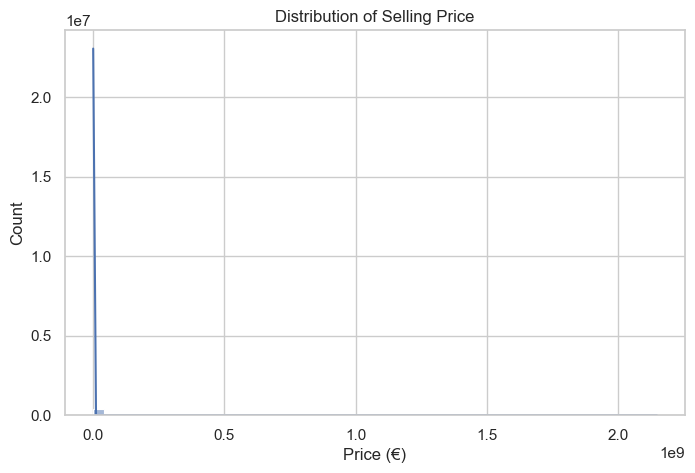

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(cleaned_df["selling_price"], bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Price (€)")
plt.ylabel("Count")
plt.show()


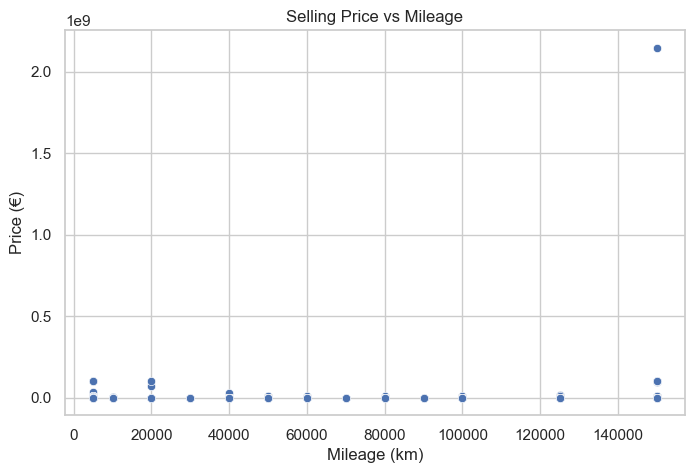

In [46]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="mileage", y="selling_price", data=cleaned_df)
plt.title("Selling Price vs Mileage")
plt.xlabel("Mileage (km)")
plt.ylabel("Price (€)")
plt.show()


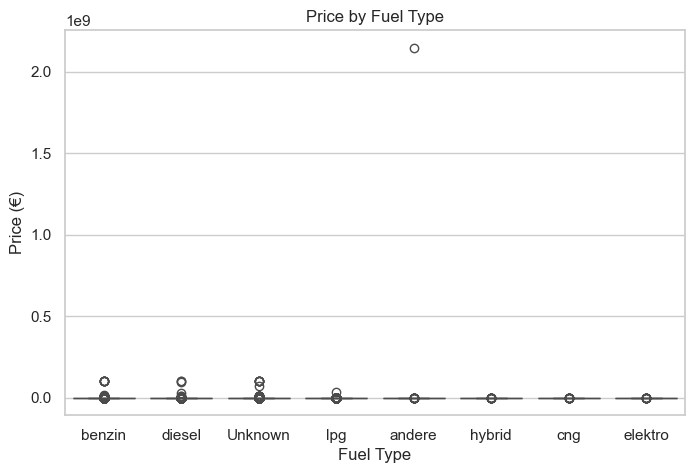

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x="fuel_type", y="selling_price", data=cleaned_df)
plt.title("Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (€)")
plt.show()


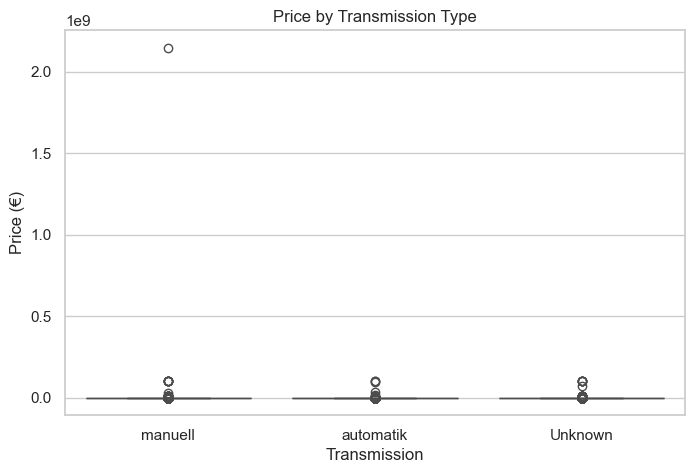

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(x="transmission", y="selling_price", data=cleaned_df)
plt.title("Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Price (€)")
plt.show()


/var/folders/6p/1s_q71y569n2dvy9bg59dp2r0000gn/T/ipykernel_9974/3418596617.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="make", y="selling_price", data=top_df, ci=None)


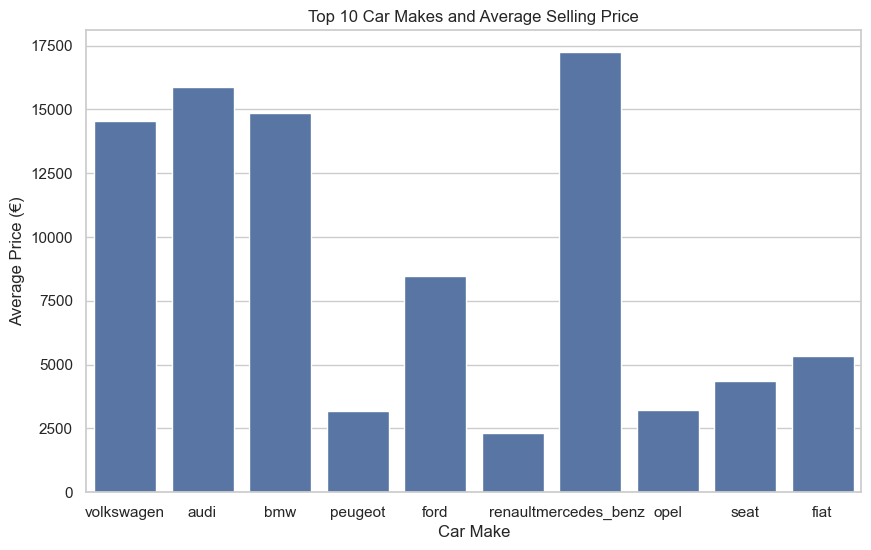

In [53]:
top_makes = cleaned_df["make"].value_counts().head(10).index
top_df = cleaned_df[cleaned_df["make"].isin(top_makes)]

plt.figure(figsize=(10,6))
sns.barplot(x="make", y="selling_price", data=top_df, ci=None)
plt.title("Top 10 Car Makes and Average Selling Price")
plt.xlabel("Car Make")
plt.ylabel("Average Price (€)")
plt.show()


In [55]:
print(cleaned_df.describe())
print(cleaned_df.groupby("fuel_type")["selling_price"].median())
print(cleaned_df.groupby("transmission")["selling_price"].median())


                year        mileage  engine_size  owners  selling_price
count  371528.000000  371528.000000          0.0     0.0   3.715280e+05
mean     2004.577997  125618.688228          NaN     NaN   1.729514e+04
std        92.866598   40112.337051          NaN     NaN   3.587954e+06
min      1000.000000    5000.000000          NaN     NaN   0.000000e+00
25%      1999.000000  125000.000000          NaN     NaN   1.150000e+03
50%      2003.000000  150000.000000          NaN     NaN   2.950000e+03
75%      2008.000000  150000.000000          NaN     NaN   7.200000e+03
max      9999.000000  150000.000000          NaN     NaN   2.147484e+09
fuel_type
Unknown     1100.0
andere       999.0
benzin      2200.0
cng         3750.0
diesel      5900.0
elektro     6100.0
hybrid     11500.0
lpg         2992.5
Name: selling_price, dtype: float64
transmission
Unknown      1100.0
automatik    6900.0
manuell      2500.0
Name: selling_price, dtype: float64


In [86]:
cleaned_df = df[[
    "make","model","year","mileage",
    "engine_size","fuel_type","transmission",
    "owners","selling_price"
]].copy()

median_price = cleaned_df["selling_price"].median()
cleaned_df["high_value"] = (cleaned_df["selling_price"] > median_price).astype(int)


In [88]:
features = ["year", "mileage", "fuel_type", "transmission"]

X = cleaned_df[features]
y = cleaned_df["high_value"]

X_encoded = pd.get_dummies(X, drop_first=True)


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)


In [92]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=4,        
    random_state=42
)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [94]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8202836917610961

Confusion Matrix:
 [[31310  5862]
 [ 7492 29642]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82     37172
           1       0.83      0.80      0.82     37134

    accuracy                           0.82     74306
   macro avg       0.82      0.82      0.82     74306
weighted avg       0.82      0.82      0.82     74306



In [96]:
import pandas as pd

importance = pd.Series(
    dt_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print(importance)


year                      0.935643
transmission_automatik    0.049675
mileage                   0.007859
fuel_type_diesel          0.006823
fuel_type_andere          0.000000
fuel_type_benzin          0.000000
fuel_type_cng             0.000000
fuel_type_elektro         0.000000
fuel_type_hybrid          0.000000
fuel_type_lpg             0.000000
transmission_manuell      0.000000
dtype: float64


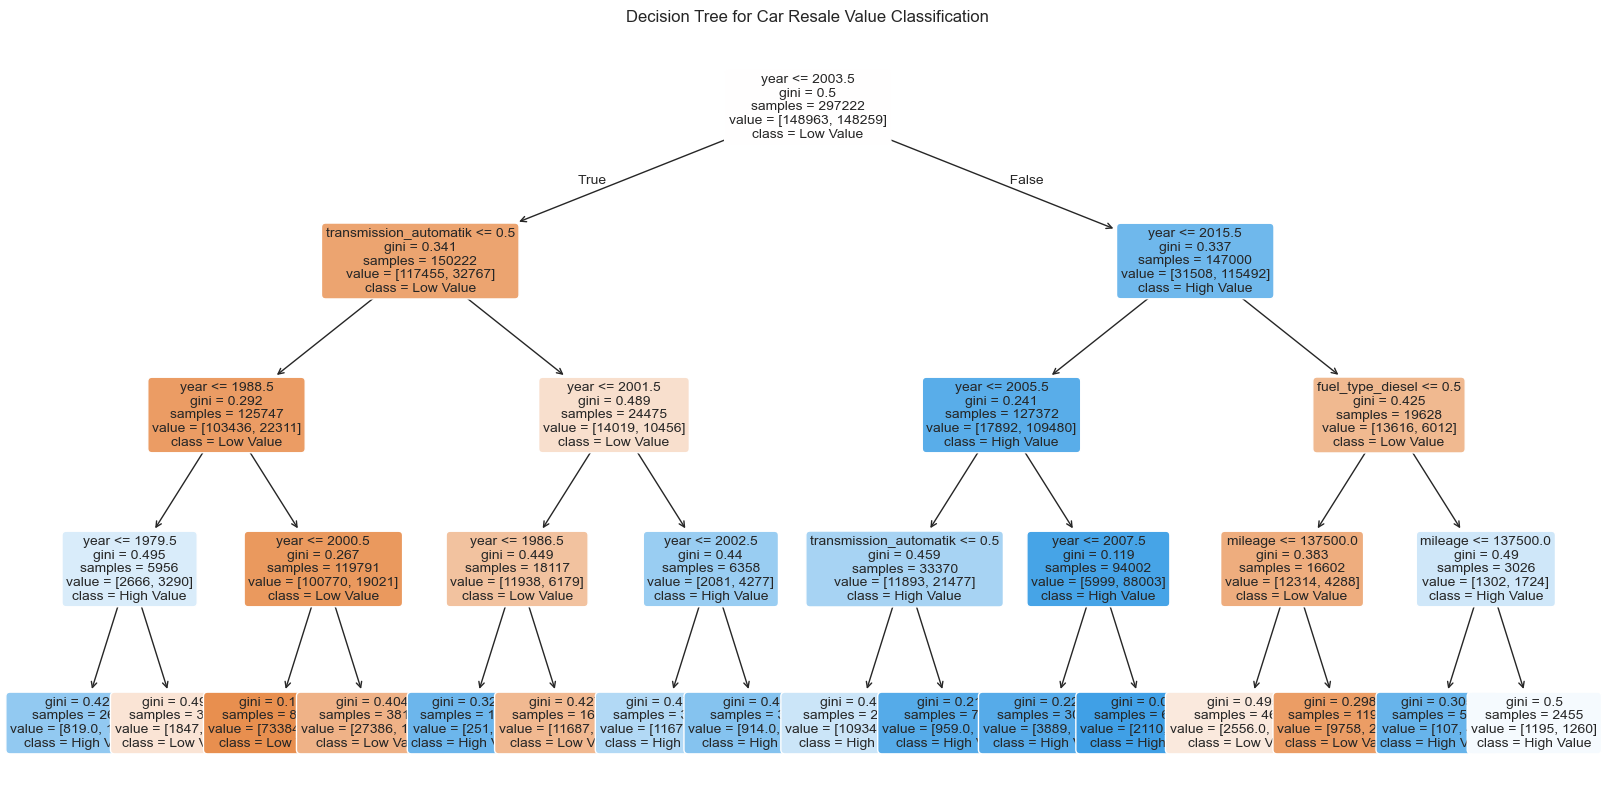

In [99]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X_encoded.columns,
    class_names=["Low Value", "High Value"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Car Resale Value Classification")
plt.show()


In [101]:
cluster_features = cleaned_df[[
    "year",
    "mileage",
    "selling_price"
]].copy()


In [103]:
cluster_features = cluster_features.dropna()


In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)



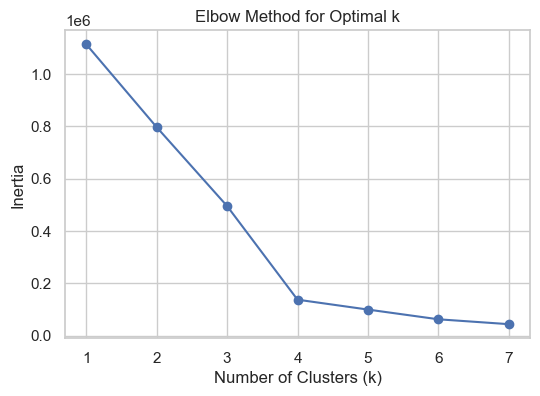

In [122]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 8), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [124]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

clustered_df = cluster_features.copy()
clustered_df["cluster"] = clusters


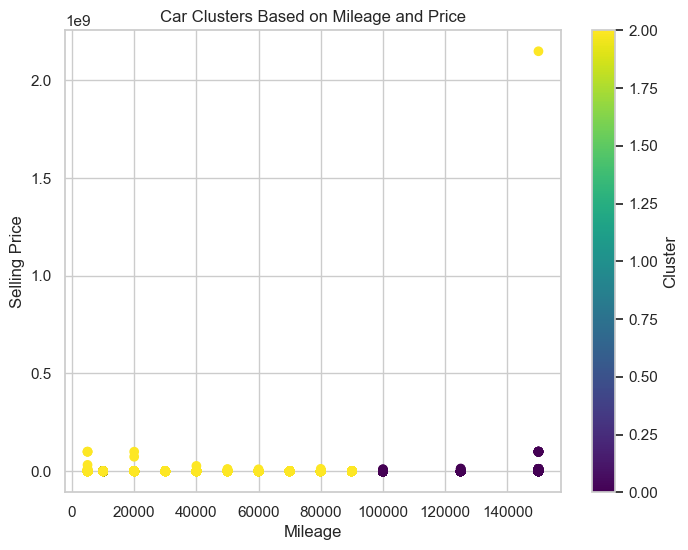

In [111]:
plt.figure(figsize=(8,6))
plt.scatter(
    clustered_df["mileage"],
    clustered_df["selling_price"],
    c=clustered_df["cluster"],
    cmap="viridis"
)

plt.xlabel("Mileage")
plt.ylabel("Selling Price")
plt.title("Car Clusters Based on Mileage and Price")
plt.colorbar(label="Cluster")
plt.show()


In [113]:
cluster_summary = clustered_df.groupby("cluster").mean()
print(cluster_summary)


                year        mileage  selling_price
cluster                                           
0        2002.508632  144071.446260    9268.674921
1        8434.666667   12121.212121   23335.257576
2        2006.998722   54779.345601   48145.695518
